# Building a Flatfile for eGSIM - using data from the Engineering Strong Motion Database

The aim of this notebook is to illustrate how to use the Engineering Strong Motion (ESM) service (https://esm-db.eu) to construct a flatfile from open strong motion data, which can be used to explore the GMMs and ground motion properties for a particular target region.

The steps of the Notebook are:

1) Use the ESM FDSN event service to find the events in a region for which data is available in ESM.

2) Use the ESM FDSN station service to create a table of the available stations in the region

3) For each event, query the ESM database to download the waveform data and metadata into an _Adaptable Seismic Data Format (ASDF)_ file. **We will show _how_ to do this but _please do not run this query/cell during the session_!**

4) Extract the intensity measure information and metadata from the ASDF files into a pandas Dataframe for each event, and then join the DataFrames to produce a complete flatfile


The region we will focus on is Southern Italy/Sicily - from 12˚E - 18˚E and 36˚N - 41˚N.

**Please note here that several steps of flatfile compilation are simplified for the purpose of running a demonstration calculation, and that a more advanced process is needed to harmonise the metadata for real world use. The flatfile itself is also demonstrative and should _not_ be used directly for hazard/risk or ground motion modelling calculations in this region!**

In this notebook we will use standard Python library functions, a typical scientific python stack (numpy/scipy/pandas/matplotlib), [Geopandas](https://geopandas.org/en/stable/) (for visualization) and [ObsPy](https://github.com/obspy/obspy/wiki/) for some of the FDSN data processing.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")

In [19]:
%matplotlib inline
import os
import io
import h5py
import requests
from requests.exceptions import HTTPError
from typing import Optional, Union, List, Dict, Tuple
import logging
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.constants import g
import pandas as pd
import geopandas as gpd
import obspy
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
logging.basicConfig(level=logging.INFO)

# Basic Setup

Here we will load in two shapefiles for Italy (Administrative Levels 0 and 1) to provide a simple basemap for reference

(36.0, 41.0)

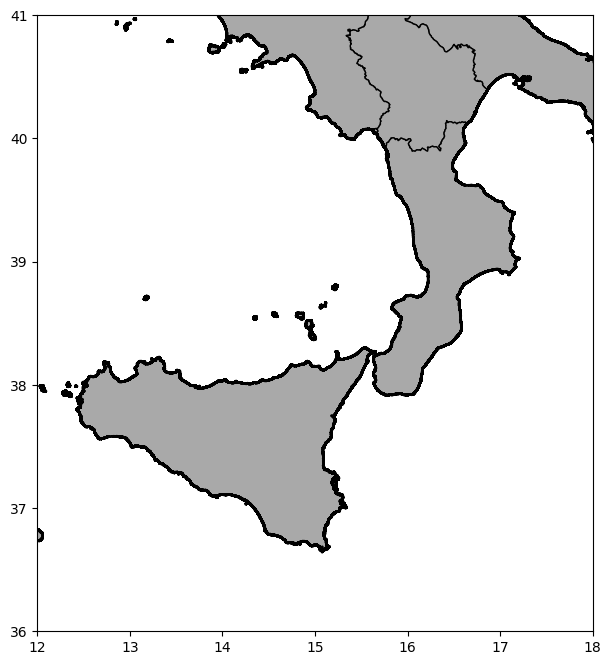

In [3]:
# Load in some basic admin shapefiles to use as a basemap
ita0 = gpd.read_file("./data/gadm40_ITA_shp/gadm40_ITA_0.shp")
ita1 = gpd.read_file("./data/gadm40_ITA_shp/gadm40_ITA_1.shp")
# The bounding box we will use for all the queries later on
w, s, e, n = bbox = (12.0, 36.0, 18.0, 41.0)
# Visualise the region
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
ax.set_xlim(w, e)
ax.set_ylim(s, n)

## Which Earthquakes have strong motion data in ESM?

In this first step we will use the ESM FDSN Event webservice to identify the earthquakes for which strong motion data _may_ be available in ESM?

In [4]:
# Stem of the ESM FDSN Webservice URL
ESM_FDSN_EVENT_URL = "https://esm-db.eu/fdsnws/event/1/query?"
# Configurable options
event_query_config = {
    "starttime": "1970-01-01T00:00:00",
    "endtime": "2026-01-01T00:00:00",
    "minlatitude": s, 
    "maxlatitude": n,
    "minlongitude": w,
    "maxlongitude": e,
    "minmagnitude": 3.0,  # Minimum magnitude of 3
    "maxmagnitude": None,
    "includeallmagnitudes": True,  # Include all the magnitudes
    "mindepth": 0.0,
    "maxdepth": 30.0, # Limit to shallow (mostly) crustal earthquakes)
    "orderby": "time-asc",  # Sort by ascending time (oldest to newest)
    "catalog": "ESM",  # Select from the ESM catalogue
    "format": "xml"  # Download the data in QuakeML
}

# Add the query options to the URL
query_string = []
for key, val in event_query_config.items():
    if val:
        query_string.append("{:s}={:s}".format(key, str(val)))
event_query_url = ESM_FDSN_EVENT_URL + "&".join(query_string)
print(event_query_url)

# Use Obspy to get the events from this query
event_catalogue = obspy.read_events(event_query_url, format="QUAKEML")
print(event_catalogue.__str__(print_all=True))

https://esm-db.eu/fdsnws/event/1/query?starttime=1970-01-01T00:00:00&endtime=2026-01-01T00:00:00&minlatitude=36.0&maxlatitude=41.0&minlongitude=12.0&maxlongitude=18.0&minmagnitude=3.0&includeallmagnitudes=True&maxdepth=30.0&orderby=time-asc&catalog=ESM&format=xml
160 Event(s) in Catalog:
2011-06-23T22:02:46.000000Z | +38.064,  +14.784 | 4.5  mw
2018-12-24T19:26:18.000000Z | +37.688,  +14.965 | 3.99 mw
2025-03-13T00:25:02.000000Z | +40.819,  +14.158 | 4.2  mb
2025-03-15T20:45:57.000000Z | +38.071,  +12.193 | 4.16 mw
2002-04-17T06:42:54.000000Z | +39.700,  +16.844 | 4.9  mw
2012-11-22T09:10:41.000000Z | +37.791,  +14.940 | 4.1  mw
2025-02-18T12:40:58.000000Z | +39.112,  +17.015 | 3.6  mw
1981-06-07T13:01:00.000000Z | +37.631,  +12.718 | 4.9  mw
1980-11-24T00:24:00.000000Z | +40.811,  +15.268 | 5.0  mw
2019-07-26T04:07:53.000000Z | +38.693,  +18.129 | 3.6  ml
2006-04-17T02:44:05.000000Z | +39.572,  +17.140 | 4.7  mw
2024-05-20T19:46:13.000000Z | +40.767,  +14.035 | 4.2  mb
1999-02-14T11:4

In [6]:
event_catalogue.__class__

obspy.core.event.catalog.Catalog

In [5]:
for ev in event_catalogue:
    print("-----")
    pref_orig = ev.preferred_origin()
    pref_mag = ev.preferred_magnitude()
    print(ev.resource_id.id, str(pref_orig.time), pref_orig.longitude, pref_orig.latitude, pref_mag.mag, pref_mag.magnitude_type,
          pref_mag.creation_info.author)
    for mag in ev.magnitudes:
        print(mag.mag, mag.magnitude_type, mag.creation_info.author)

-----
smi:esm-db.eu/fdsnws/event/1/query?event_id=IT-2011-0110 2011-06-23T22:02:46.000000Z 14.784 38.064 4.5 mw INGV-CNT_Seismic_Bulletin
3.85 ms ISC-webservice
4.5 mw INGV-CNT_Seismic_Bulletin
5.2 ml EMSC-CSEM
4.3 mb USGS-webservice
-----
smi:esm-db.eu/fdsnws/event/1/query?event_id=EMSC-20181224_0000148 2018-12-24T19:26:18.000000Z 14.965 37.688 3.99 mw Pondrelli_et_al_2002_dataset
3.0 ms ISC-webservice
4.0 ml INGV-TERREMOTI
3.99 mw Pondrelli_et_al_2002_dataset
4.0 ml EMSC-CSEM
-----
smi:esm-db.eu/fdsnws/event/1/query?event_id=INT-41908352 2025-03-13T00:25:02.000000Z 14.1575 40.818833 4.2 mb EMSC-CSEM
4.6 md INGV-TERREMOTI
4.2 mb USGS-webservice
4.2 mb EMSC-CSEM
4.2 mb ISC-webservice
-----
smi:esm-db.eu/fdsnws/event/1/query?event_id=INT-20250315_0000212 2025-03-15T20:45:57.000000Z 12.193 38.0708 4.16 mw Pondrelli_et_al_2002_dataset
4.0 mb USGS-webservice
4.06 mw ISC-webservice
4.1 mw INGV-TERREMOTI
4.2 mb EMSC-CSEM
4.16 mw Pondrelli_et_al_2002_dataset
-----
smi:esm-db.eu/fdsnws/event/1

In [10]:
def build_source_information_table(catalogue: obspy.core.event.catalog.Catalog) -> pd.DataFrame:
    """Extract the information from the Obspy catalogue to build a simple table
    of event parameters

    Args:
        catalogue: The Obspy earthquke catalogue

    Returns:
        source_table: The event source table (as a pandas Dataframe)
    """
    source_info = {}
    for event in catalogue:
        event_id = event.resource_id.id.split("=")[1]
        pref_origin = event.preferred_origin()
        pref_mag = event.preferred_magnitude()
        pref_foc_mech = event.preferred_focal_mechanism()
        event_source = {
            "event_id": event_id,
            "event_datetime": str(pref_origin.time).replace("Z", ""),
            "event_longitude": pref_origin.longitude,
            "event_latitude": pref_origin.latitude,
            "event_depth": pref_origin.depth,
            "origin_author": pref_origin.creation_info.author,
            "mag": pref_mag.mag,
            "mag_type": pref_mag.magnitude_type,
            "mag_author": pref_mag.creation_info.author,
            "strike_1": np.nan,
            "dip_1": np.nan,
            "rake_1": np.nan,
            "strike_2": np.nan,
            "dip_2": np.nan,
            "rake_2": np.nan,
            "rup_top_depth": np.nan,
            "rup_width": np.nan,
            "rup_length": np.nan,
            "rup_strike": np.nan,
            "rup_dip": np.nan,
            "rup_rake": np.nan
        }
        if pref_foc_mech:
            npls = pref_foc_mech.nodal_planes
            if npls:
                if npls.nodal_plane_1:
                   event_source["strike_1"] = npls.nodal_plane_1.strike
                   event_source["dip_1"] = npls.nodal_plane_1.dip
                   event_source["rake_1"] = npls.nodal_plane_1.rake
                if npls.nodal_plane_2:
                    event_source["strike_2"] = npls.nodal_plane_2.strike
                    event_source["dip_2"] = npls.nodal_plane_2.dip
                    event_source["rake_2"] = npls.nodal_plane_2.rake
        source_info[event_id] = pd.Series(event_source)
    source_table = pd.DataFrame(source_info).T
    source_table.sort_values("event_datetime", inplace=True)
    return source_table
            
        

In [11]:
source_table = build_source_information_table(event_catalogue)
source_table

,event_id,event_datetime,event_longitude,event_latitude,event_depth,origin_author,mag,mag_type,mag_author,strike_1,...,rake_1,strike_2,dip_2,rake_2,rup_top_depth,rup_width,rup_length,rup_strike,rup_dip,rup_rake
IT-1978-0002,IT-1978-0002,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,ISC-webservice,5.2,mw,Global_CMT,270.0,...,-72.0,66.0,52.0,-105.0,NaN,NaN,NaN,NaN,NaN,NaN
IT-1978-0003,IT-1978-0003,1978-04-15T23:29:12.000000,15.183,38.228,37.0,USGS-webservice,4.1,ml,ING_Catalogue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IT-1978-0004,IT-1978-0004,1978-04-15T23:33:47.000000,15.11,38.27,22.0,ING_Catalogue,6.0,mw,Global_CMT,147.0,...,180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IT-1980-0002,IT-1980-0002,1980-02-20T02:34:01.000000,16.152,39.286,12.0,ING_Catalogue,4.4,mw,RCMT-INGV,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IT-1980-0007,IT-1980-0007,1980-05-14T01:41:02.000000,15.834,40.365,25.0,ING_Catalogue,4.8,mw,RCMT-INGV,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INT-43451602,INT-43451602,2025-07-18T07:14:22.000000,14.155667,40.817,2.53,SURVEY-INGV,4.0,md,INGV-TERREMOTI,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INT-43928662,INT-43928662,2025-09-01T02:55:45.000000,14.137167,40.823,2.29,SURVEY-INGV,4.0,md,INGV-TERREMOTI,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INT-44509142,INT-44509142,2025-10-24T12:40:58.000000,14.8185,40.9652,13.8,INGV-BULLETIN,3.7,mw,INGV-TERREMOTI,288.0,...,80.0,124.0,38.0,102.0,NaN,NaN,NaN,NaN,NaN,NaN
INT-44522982,INT-44522982,2025-10-25T19:49:18.000000,14.8155,40.9695,14.9,INGV-BULLETIN,4.0,mw,INGV-TERREMOTI,258.0,...,148.0,358.0,59.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Export to csv - for safe keeping!
source_table.to_csv("SItaly_ESM_Catalogue.csv", sep=",")

### Visualize the catalogue

Text(0, 0.5, 'Hypocentre Depth (km)')

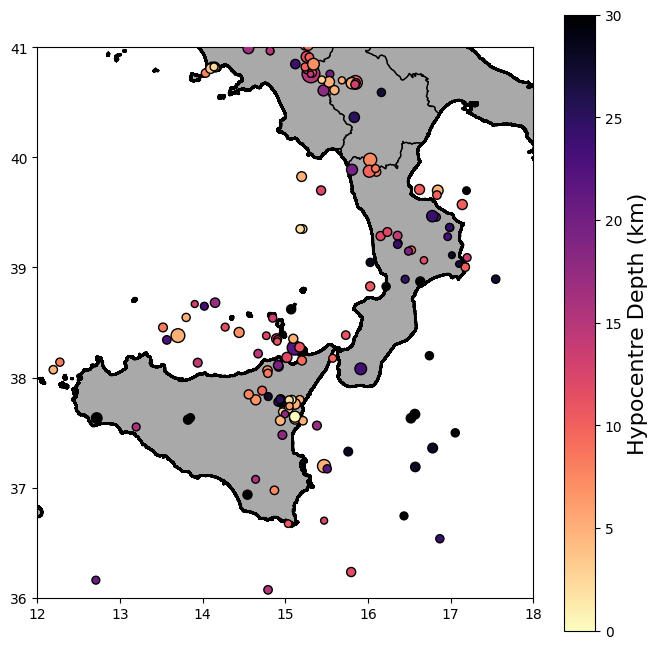

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
cax = ax.scatter(
    source_table["event_longitude"], source_table["event_latitude"],
    c=source_table["event_depth"].to_numpy(),
    s=0.5 * source_table["mag"].to_numpy().astype(float) ** 3.0,
    marker="o", edgecolor="k", cmap="magma_r",
    norm=Normalize(0.0, 30.0), label="Events", zorder=4
)
ax.set_xlim(w, e)
ax.set_ylim(s, n)
cbar = fig.colorbar(cax)
cbar.ax.set_ylabel("Hypocentre Depth (km)", fontsize=16)

## Which Stations in this region provide data to ESM?

Though we won't use this data directly, we will also show how to use the ESM FDSN station service to find the available stations in this region. 

In [14]:
# Set the URL stem of the ESM Station Webservice
ESM_FDSN_STATION_URL = "https://esm-db.eu/fdsnws/station/1/query?"

# Set the configurable properties
station_query_config = {
    "level": "channel",  # Separate out by channel (separate entries for co-located strong and weak motion!)
    "minlatitude": s - 2.0, # Extend the search area by 2 degrees in every direction
    "maxlatitude": n + 2.0,
    "minlongitude": w - 2.0,
    "maxlongitude": e + 2.0,
    "channel": "HN*,HH*,HG*",  
    "format": "text"
}
# Add the query information to the URL
query_string = []
for key, val in station_query_config.items():
    if val:
        query_string.append("{:s}={:s}".format(key, str(val)))
station_query_url = ESM_FDSN_STATION_URL + "&".join(query_string)
print(station_query_url)

https://esm-db.eu/fdsnws/station/1/query?level=channel&minlatitude=34.0&maxlatitude=43.0&minlongitude=10.0&maxlongitude=20.0&channel=HN*,HH*,HG*&format=text


In [15]:
# As the FDSN information is a text file with | as the delimiter, then this can be read directly using Pandas
stations = pd.read_csv(station_query_url, sep="|")
stations

,network_code,network_restricted_status,station_code,station_latitude,station_longitude,station_elevation_m,station_name,station_restricted_status,sensor_channel_code,sensor_location_code,sensor_latitude,sensor_longitude,sensor_elevation_m,sensor_depth_m
0,1V,public,ACC7,40.49131,16.15689,755,NaN,public,HNZ,0.0,40.49131,16.15689,755,0
1,1V,public,ACC7,40.49131,16.15689,755,NaN,public,HNN,0.0,40.49131,16.15689,755,0
2,1V,public,ACC7,40.49131,16.15689,755,NaN,public,HNE,0.0,40.49131,16.15689,755,0
3,1V,public,AGR7,40.35646,15.82829,602,NaN,public,HNZ,0.0,40.35646,15.82829,602,0
4,1V,public,AGR7,40.35646,15.82829,602,NaN,public,HNN,0.0,40.35646,15.82829,602,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4618,ZM,public,T1365,40.70139,13.91815,130,Barano (NA),public,HNN,NaN,40.70139,13.91815,130,0
4619,ZM,public,T1365,40.70139,13.91815,130,Barano (NA),public,HNE,NaN,40.70139,13.91815,130,0
4620,ZM,public,T1366,40.73727,13.90458,213,Casamicciola NA,public,HNZ,NaN,40.73727,13.90458,213,0
4621,ZM,public,T1366,40.73727,13.90458,213,Casamicciola NA,public,HNN,NaN,40.73727,13.90458,213,0


### Put everything together on a map

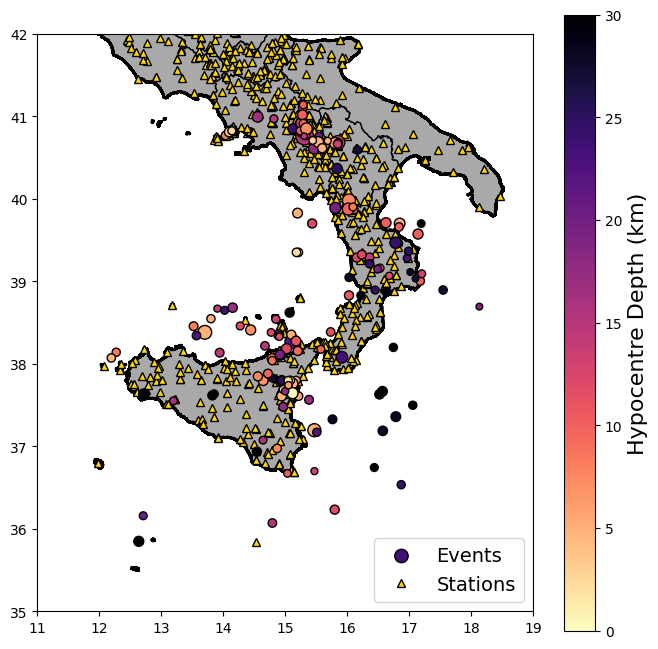

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
cax = ax.scatter(source_table["event_longitude"], source_table["event_latitude"],
                 c=source_table["event_depth"].to_numpy(), s=0.5 * source_table["mag"].to_numpy().astype(float) ** 3.0,
                 marker="o", edgecolor="k", cmap="magma_r", norm=Normalize(0.0, 30.0), label="Events", zorder=4)
unique_stations = stations.drop_duplicates(["network_code", "station_code"], inplace=False)
ax.plot(unique_stations["station_longitude"], unique_stations["station_latitude"], "^", mec="k", mfc="gold", label="Stations")
ax.set_xlim(w - 1, e + 1)
ax.set_ylim(s - 1, n + 1)
cbar = fig.colorbar(cax)
cbar.ax.set_ylabel("Hypocentre Depth (km)", fontsize=16)
ax.legend(loc="lower right", fontsize=14)

# Download Waveform Data from ESM Event-Data Webservice

In this next step we will use the ESM Event-Data webservice to go through the catalogue event-by-event, downloading the available waveforms for that event and then storing the waveform data in an ASDF file for that event.

**This may take some time to run depending on the network traffic and internet connection. Please _do not_ run this during the session. It is included here for illustration. The resulting data should be available in the directory `./data/esm_waveforms/`**

In [77]:
import time

# URL stem for the event-data FDSN web service
ESM_EVENT_DATA_URL = "https://esm-db.eu/esmws/eventdata/1/query?"

# Configuration options
event_data_config = {
    "catalog": "ESM",
    "channel": "HN*,HH*,HG*",  # Channels for data - strong motion (HN, HG) and broadband velocity (HH)
    "format": "hdf5",  # Stores the data in ASDF (hdf5) formay
    "processing-type": "MP,AP",  # Select manually and automatically processed records
    "data-type": "ACC,SD",  # Include for each record the acceleration waveforms and the response spectral displacements
    "add-xml": "True",  # Add on event metadata in XML
    "add-auxiliary-data": "True"  # Add on auxiliary data - this is CRITICAL because it contains important metadata needed for eGSIM
}

# Where to store the waveforms
output_directory = os.path.join("data", "esm_waveforms")
#output_directory = "./data/esm_waveforms"


def download_esm_waveform_data(event_table: pd.DataFrame, config: Dict, output_folder: str):
    """Function to execute a bulk download of waveform data event-by-event from ESM using
    the FDSN event-data service.

    Args:
        event_table: The table of events (see above)
        config: The additional query configuration options
        output_folder: The path to the directory to store the data (will be removed if it exists!)
    """
    if os.path.exists(output_folder):
        os.system("rm -r %s" % output_folder)
    os.mkdir(output_folder)
    query_string = []
    for key, val in config.items():
        if val:
            query_string.append("{:s}={:s}".format(key, str(val)))
    i = 1
    for ev_id, row in event_table.iterrows():
        event_data_query_url = ESM_EVENT_DATA_URL + f"eventid={ev_id}&" + "&".join(query_string)
        output_filename = os.path.join(output_folder, f"{ev_id}.hdf5")
        logging.info("Query URL: %s" % event_data_query_url)
        response = requests.get(event_data_query_url)
        if response.status_code == 200:
            # Successful download
            with open(output_filename, "wb") as file:
                file.write(response.content)
            logging.info("---- Successfully downloaded to %s" % output_filename)
        else:
            logging.info("---- Failed download")
            logging.info("---- %s" % response.reason)
        time.sleep(2)  # Avoid overloading queries too rapidly
    logging.info("Done!")
    return

# Execute the download
#download_esm_waveform_data(source_table, event_data_config, output_directory)

INFO:root:Query URL: https://esm-db.eu/esmws/eventdata/1/query?eventid=IT-1978-0002&catalog=ESM&channel=HN*,HH*,HG*&format=hdf5&processing-type=MP,AP&data-type=ACC,SD&add-xml=True&add-auxiliary-data=True
INFO:root:---- Successfully downloaded to ./data/esm_waveforms/IT-1978-0002.hdf5
INFO:root:Query URL: https://esm-db.eu/esmws/eventdata/1/query?eventid=IT-1978-0003&catalog=ESM&channel=HN*,HH*,HG*&format=hdf5&processing-type=MP,AP&data-type=ACC,SD&add-xml=True&add-auxiliary-data=True
INFO:root:---- Successfully downloaded to ./data/esm_waveforms/IT-1978-0003.hdf5
INFO:root:Query URL: https://esm-db.eu/esmws/eventdata/1/query?eventid=IT-1978-0004&catalog=ESM&channel=HN*,HH*,HG*&format=hdf5&processing-type=MP,AP&data-type=ACC,SD&add-xml=True&add-auxiliary-data=True
INFO:root:---- Successfully downloaded to ./data/esm_waveforms/IT-1978-0004.hdf5
INFO:root:Query URL: https://esm-db.eu/esmws/eventdata/1/query?eventid=IT-1980-0002&catalog=ESM&channel=HN*,HH*,HG*&format=hdf5&processing-type=M

# Prepare the flatfile for eGSIM

At this point we should have all the data we need in the `./data/esm_waveforms` directory. Now we need to extract the parameters for each record and turn it into a _flatfile_ (i.e. a one-row-per-record table containing both the metadata and parametric intensity measures)

### What data should the flatfile contain?

Using the eGSIM platform we want to make residual comparisons for four GMMs:

1) Kotha et al. (2020) - ESHM20 adaptation
2) Bindi et al. (2014) - earlier RESORCE model
3) Boore et al. (2014) - NGA West 2 GMM
4) Cauzzi et al. (2015) - Global model (shown to work quite well in Italy - Lanzano et al., 2020)

Using the eGSIM tool to define the required fields in the flatfile for these models (https://egsim.gfz.de/flatfile), the required fields are:


| **Field** | **Property** | **Data Type** | **Description** |
| ----- | -------- | --------- | ----------- |
| PGA |intensity measure | numeric float | Peak ground acceleration, in g |
| PGV | intensity measure | numeric float | Peak ground velocity, in cm/s |
| SA(⋯)	| intensity measure | numeric float | Spectral Acceleration, in g. SA columns must be supplied in the form "SA(P)", where P denotes the SA period, in seconds. The period range supported by all 4 selected models is [0.02, 3.0] (endpoints included). If a specific period is required for computation but missing in the flatfile, the relative SA value will be determined for each record by logarithmic interpolation (log10), but in this case the flatfile must contain at least two distinct SA columns |
| evt_depth | rupture parameter | numeric float | event depth (hypocentral depth, in km). Alternative valid names: hypo_depth, event_depth |
| evt_id | rupture parameter | string | The ID of the seismic event, used to determine when two records originate from the same earthquake. IDs do not have a specific data type but are usually either numeric integers (recommended) or string of text (discouraged, especially for flatfiles with many distinct event IDs). Alternative valid name: event_id |
| mag |	rupture parameter | numeric float | event magnitude. Alternative valid name: magnitude |
| rake | rupture parameter | numeric float | the direction the hanging wall moves, relative to the fault strike (deg). Hint: in case of more components available (e.g. from web services), the correct one should be inferred by the user from the rupture, or can be chosen randomly if no information is available |
| region | site parameter | numeric integer, categorical, to be chosen from 0, 1, 2, 3, 4, 5 | The ESHM2020 attenuation cluster region to which the site belongs (https://doi.org/10.1007/s10518-020-00899-9). 0 (default when missing): unknown, 1: average / slower, 2: average / faster, 3: fast, 4: average, 5: very slow |
| rjb |	distance measure | numeric float | Joyner-Boore distance (in km). Missing data (e.g., empty cell, NaN, column not provided) will be replaced with the epicentral distance, if present |
| rrup | distance measure | numeric float | rupture_distance (in km). Missing data (e.g., empty cell, NaN, column not provided) will be replaced with the hypocentral distance, if present |
| vs30 | site parameter | numeric float | Average shear wave velocity in the top 30 m, in m/s |
| vs30measured | site parameter | boolean | whether or not the Vs30 is measured (default true) |


In addition to the above eseential informaiton, we will add on:

`repi`: Epicentral distance (km)

`rhypo`: The hypocentral distance (km)

`z1pt0`, `z2pt5`: The basin depth terms (inferred from Vs30)

`event_longitude`, `event_latitude`, `station_longitude`, `station_latitude`: Locations of the events and stations

`network`, `station_code`, `location`, `channel`: Station identifiers (concatenated into a single station ID)

In [20]:
def get_velocity_displacement(
    time_step: float,
    acceleration: np.ndarray
) ->Tuple[np.ndarray, np.ndarray]:
    """
    Returns the velocity and displacment time series using simple integration

    Args:
        time_step: Time-series time-step (s)
        acceleration: Acceleration time-history in cm/s/s
    :returns:
        velocity - Velocity Time series (cm/s)
        displacement - Displacement Time series (cm)
    """
    velocity = cumulative_trapezoid(acceleration, x=None, dx=time_step, initial=0.)
    displacement = cumulative_trapezoid(velocity, x=None, dx=time_step, initial=0.)
    return velocity, displacement


# Needed to get psuedo-acceleration spectra from spectral displacement
OMEGA2 = lambda t: 4.0 * (np.pi ** 2.0) / (t ** 2.0)

# Create a default set of target periods
DEFAULT_PERIODS = np.array(
    [0.01, 0.02, 0.022, 0.025, 0.029, 0.03, 0.032, 0.035,
     0.036, 0.04, 0.042, 0.044, 0.045, 0.046, 0.048, 0.05,
     0.055, 0.06, 0.065, 0.067, 0.07, 0.075, 0.08, 0.085,
     0.09, 0.095, 0.1, 0.11, 0.12, 0.13, 0.133, 0.14,
     0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.22, 0.24,
     0.25, 0.26, 0.28, 0.29, 0.3, 0.32, 0.34, 0.35,
     0.36, 0.38, 0.4, 0.42, 0.44, 0.45, 0.46, 0.48,
     0.5, 0.55, 0.6, 0.65, 0.667, 0.7, 0.75, 0.8,
     0.85, 0.9, 0.95, 1.0, 1.1, 1.2, 1.3, 1.4,
     1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.2, 2.4,
     2.5, 2.6, 2.8, 3.0, 3.2, 3.4, 3.5, 3.6,
     3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.5,
     6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
)


def vs30_to_z1pt0_cy14(vs30: np.ndarray, japan: bool = False) -> np.ndarray:
    """
    Returns the estimate depth to the 1.0 km/s velocity layer based on Vs30
    from Chiou & Youngs (2014) California model or Japan model

    Args:
        vs30: Input Vs30 values in m/s
        japan: If true then this returns the Z1.0 values according to the Japan model,
               otherwise the California model
    Returns:
            Z1.0 values in m
    """
    if japan:
        c1 = 412.0**2.0
        c2 = 1360.0**2.0
        return np.exp((-5.23 / 2.0) * np.log((np.power(vs30, 2.0) + c1) / (c2 + c1)))
    else:
        c1 = 571.0**4.0
        c2 = 1360.0**4.0
        return np.exp((-7.15 / 4.0) * np.log((vs30**4.0 + c1) / (c2 + c1)))


def vs30_to_z2pt5_cb14(vs30: np.ndarray, japan: bool = False) -> np.ndarray:
    """
    Converts vs30 to depth to 2.5 km/s interface using model proposed by
    Campbell & Bozorgnia (2014)

    Args:
        vs30: Input Vs30 values in m/s
        japan: If true then this returns the Z1.0 values according to the Japan model,
               otherwise the California model
    Returns:
            Z2.5 values in km
    """
    if japan:
        return np.exp(5.359 - 1.102 * np.log(vs30))
    else:
        return np.exp(7.089 - 1.144 * np.log(vs30))


def get_intensity_measures_for_station(
    fle: h5py.File,
    stn: str,
    target_sa_periods: np.ndarray
) -> Tuple[Dict, Dict]:
    """Retreives the pseudo-acceleration spectra and peak measures (PGA, PGV, PGD)
    for the waveform components in the record and then combines them to give
    a resolved geometric mean horizontal motion.

    Args:
        fle: The open h5py.File object for the event
        stn: The station ID
        target_sa_periods: The periods for which the spectral acceleration should be calculated

    Returns:
        horizontal_ims: Dictionary containing resolved horizontal ground motion for each IM
        ims: Dictionary containing the ground motion intensity measures for each individual component
    """
    wvfs = list(fle[f"Waveforms/{stn}"])
    ims = {}
    # Get the individual peak intensity measures from the acceleration time-series
    for wvf in wvfs:
        if wvf.endswith("acc_mp"):
            wv_id = wvf.split("__")[0]
            network, station, location, channel = wv_id.upper().split(".")
            accel = fle[f"Waveforms/{stn}/{wvf}"][:]
            time_step = 1.0 / fle[f"Waveforms/{stn}/{wvf}"].attrs["sampling_rate"]
            velocity, displacement = get_velocity_displacement(time_step, accel)
            ims[channel[-1]] = {"PGA": np.max(np.fabs(accel)) / (100.0 * g), # Convert cm/s/s to g
                                "PGV": np.max(np.fabs(velocity)),
                                "PGD": np.max(np.fabs(displacement))}
        elif wvf == "StationXML":
            continue
            
    stn_id = stn.replace(".", "_")
    # Get the pseudo-accleration spectra
    for spec in list(fle[f"AuxiliaryData/Spectra/{stn_id}"]):
        spec_info = spec.upper().split("_")
        channel = spec_info[1]
        periods = fle[f"AuxiliaryData/Spectra/{stn_id}/{spec}"][0, :]
        disp_spec = fle[f"AuxiliaryData/Spectra/{stn_id}/{spec}"][1, :]
        # Log-log interpolation from input periods to standard target periods
        disp_spec = 10.0 ** np.interp(
            np.log10(target_sa_periods),
            np.log10(periods),
            np.log10(disp_spec)
        )
        for i in range(disp_spec.shape[0]):
            period = target_sa_periods[i]
            ims[channel[-1]]["SA({:.5f})".format(period)] = (OMEGA2(period) * disp_spec[i]) / (100.0 * g)
    
    # Get the as-recorded geometric mean (for the current example)
    horizontal_ims = {}
    for i_m in list(ims["E"]):
        horizontal_ims[i_m] = np.sqrt(float(ims["E"][i_m]) * float(ims["N"][i_m]))
    return horizontal_ims, ims


def parse_event_asdf_to_dataframe(
    event_id: str,
    filename: str,
    event_source_table: Union[pd.DataFrame, Dict],
    target_sa_periods: Optional[Union[List, np.ndarray]] = DEFAULT_PERIODS
) -> pd.DataFrame:
    """Takes the ground motion data from each event file and parses this
    to a dataframe containing both the metadata and intensity measures

    Args:
        event_id: The unique event ID
        filename: The path to the hdf5 file
        event_source_table: The source table for this specific event
        target_sa_periods: The target periods to calculate spectral acceleration

    Returns:
        All records metadata and horizontal intensity measured for this event as a single
        pandas Dataframe
    """
    assert os.path.exists(filename), f"File for event {event_id}: {filename} not found!"
    
    if isinstance(target_sa_periods, list):
        target_sa_periods = np.array(target_sa_periods)

    assert np.all(target_sa_periods[:-1] < target_sa_periods[1:]),\
        "Input target periods must be monotonically ascending"

    # Open the ASDF file
    fle = h5py.File(filename, "r")
    # List the stations
    station_list = list(fle["Waveforms"])
    flatfile_event = {}
    # Set strike, dip, rake information
    if np.isnan(event_source_table["rake_2"]):
        if np.isnan(event_source_table["rake_1"]):
            # No focal mechanism
            foc_mech = {
                "strike": 0.0, "dip": 90.0, "rake": 0.0,
                "strike_1": np.nan, "dip_1": np.nan, "rake_1": np.nan,
                "strike_2": np.nan, "dip_2": np.nan, "rake_2": np.nan,
            }
        else:
            # Only the first nodal plane exists
            foc_mech = {
                "strike": event_source_table["strike_1"],
                "dip": event_source_table["dip_1"],
                "rake": event_source_table["rake_1"],
                "strike_1": event_source_table["strike_1"],
                "dip_1": event_source_table["dip_1"],
                "rake_1": event_source_table["rake_1"],
                "strike_2": np.nan, "dip_2": np.nan, "rake_2": np.nan,
            }
    else:
        # Both nodal planes available - select at random
        selected_plane = str(np.random.randint(1, 3, size=1)[0])
        foc_mech = {
                "strike": event_source_table[f"strike_{selected_plane}"],
                "dip": event_source_table[f"dip_{selected_plane}"],
                "rake": event_source_table[f"rake_{selected_plane}"],
                "strike_1": event_source_table["strike_1"],
                "dip_1": event_source_table["dip_1"],
                "rake_1": event_source_table["rake_1"],
                "strike_2": event_source_table["strike_2"],
                "dip_2": event_source_table["dip_2"],
                "rake_2": event_source_table["rake_2"],
            }
    # For each station get the IMs and metadata, then combine everything
    # into a dataframe
    for stn in station_list:
        if stn.replace(".", "_") not in list(fle["AuxiliaryData/Headers"]):
            logging.info("No spectra for station %s" % stn)
            continue
        # Get the horizontal intensity measures
        horizontal_ims = get_intensity_measures_for_station(fle, stn, target_sa_periods)[0]
 
        # Get station metadata
        stn_id = stn.replace(".", "_")
        folder = list(fle[f"AuxiliaryData/Headers/{stn_id}"])[0]
        attrs = fle[f"AuxiliaryData/Headers/{stn_id}/{folder}"].attrs
        network, station, location, instrument = attrs["network"], attrs["station_code"],\
             attrs["location"], attrs["instrument"]
        site_id = ".".join([network, station, location, instrument])
        
        # Get station xml data
        stn_data = fle["Waveforms/{:s}/StationXML".format(stn)][:].tobytes().strip()
        with io.BytesIO(stn_data) as buf:
            station_data = obspy.read_inventory(buf, format="stationxml")
            channel = station_data.get_contents()["channels"][0]
            coords = station_data.get_coordinates(channel)
        # Create unique waveform ID by concatenating event and site IDs
        wfid = f"{event_id}|{site_id}"
        # Get the site vs30 data by order of preference (profile -> topography -> geology)
        if attrs["vs30_m_s_from_vs_profile"]:
            vs30 = float(attrs["vs30_m_s_from_vs_profile"])
            vs30measured = True
        elif attrs["vs30_m_s_from_topography"]:
            vs30 = float(attrs["vs30_m_s_from_topography"])
            vs30measured = False
        elif attrs["vs30_m_s_from_geology"]:  # N.B. this is removed in ESM v3.0
            vs30 = float(attrs["vs30_m_s_from_geology"])
            vs30measured = False
        else:
            vs30 = np.nan
            vs30measured = False
        # Take distances from metadata
        repi = float(attrs["epicentral_distance_km"])
        rhypo = float(attrs["hypocentral_distance_km"])
        # Quick hack - if rjb or rrup are not defined then take epicentral and hypocentral distance respectively
        rjb = float(attrs["fault_distance_km"]) if attrs["fault_distance_km"] else repi
        rrup = float(attrs["rupture_distance_km"]) if attrs["rupture_distance_km"] else rhypo

        metadata = {
            "event_id": event_id,
            "site_id": site_id,
            "wfid": wfid,
            # Event metadata
            "event_datetime": str(event_source_table["event_datetime"]),
            "event_longitude": event_source_table["event_longitude"],
            "event_latitude": event_source_table["event_latitude"],
            "event_depth": event_source_table["event_depth"],
            "mag": event_source_table["mag"],
            "mag_type": event_source_table["mag_type"],
            "strike": foc_mech["strike"],
            "dip": foc_mech["dip"],
            "rake": foc_mech["rake"],
            "strike_1": foc_mech["strike_1"],
            "dip_1": foc_mech["dip_1"],
            "rake_1": foc_mech["rake_1"],
            "strike_2": foc_mech["strike_2"],
            "dip_2": foc_mech["dip_2"],
            "rake_2": foc_mech["rake_2"],           
            "network": network,
            "station": station,
            "location": location,
            "instrument": instrument,
            "station_longitude": coords["longitude"],
            "station_latitude": coords["latitude"],
            "station_elevation": coords["elevation"],
            "station_depth": coords["local_depth"],
            "vs30": vs30,
            "vs30measured": vs30measured,
            "z1pt0": vs30_to_z1pt0_cy14(vs30),
            "z2pt5": vs30_to_z2pt5_cb14(vs30),
            "region": 0,
            "repi": repi,
            "rhypo": rhypo,
            "rjb": rjb,
            "rrup": rrup,
            "high_pass_period": 1.0 / float(attrs["low_cut_frequency_hz"]),
            "low_pass_period": 1.0 / float(attrs["high_cut_frequency_hz"])
        }
        metadata.update(horizontal_ims)
        flatfile_event[wfid] = metadata
    fle.close()
    return pd.DataFrame(flatfile_event).T

In [21]:
# Show what the event dataframe looks like
ev_id = "IT-1980-0021"
df = parse_event_asdf_to_dataframe(
    ev_id,
    f"./data/esm_waveforms/{ev_id}.hdf5",
    source_table.loc[ev_id],
    
)
df

,event_id,site_id,wfid,event_datetime,event_longitude,event_latitude,event_depth,mag,mag_type,strike,...,SA(5.50000),SA(6.00000),SA(6.50000),SA(7.00000),SA(7.50000),SA(8.00000),SA(8.50000),SA(9.00000),SA(9.50000),SA(10.00000)
IT-1980-0021|E.FMC.00.HN,IT-1980-0021,E.FMC.00.HN,IT-1980-0021|E.FMC.00.HN,1980-11-25T14:57:54.000000,15.324,40.77,10.0,4.3,ml,0.0,...,0.000147,0.000117,0.000099,0.000086,0.000073,0.000062,0.000052,0.000045,0.000038,0.000033


### Finally, process all events and concatenate into a single dataframe

In [22]:
dfs_by_event = []
data_directory = os.path.join("data", "esm_waveforms")


for evid in source_table["event_id"]:
    # Get the event file
    fname = os.path.join(data_directory, f"{evid}.hdf5")
    if not os.path.exists(fname):
        # No data was downloaded for that event
        continue
    logging.info(f"Parsing event {evid} file {fname} to table")
    df = parse_event_asdf_to_dataframe(
        evid,
        fname,
        source_table.loc[evid].to_dict(),
        DEFAULT_PERIODS
    )
    dfs_by_event.append(df)
flatfile = pd.concat(dfs_by_event, axis=0, ignore_index=True)
flatfile.set_index("wfid", drop=True, inplace=True)
flatfile

INFO:root:Parsing event IT-1978-0002 file data/esm_waveforms/IT-1978-0002.hdf5 to table
INFO:root:Parsing event IT-1978-0003 file data/esm_waveforms/IT-1978-0003.hdf5 to table
INFO:root:Parsing event IT-1978-0004 file data/esm_waveforms/IT-1978-0004.hdf5 to table
INFO:root:Parsing event IT-1980-0002 file data/esm_waveforms/IT-1980-0002.hdf5 to table
INFO:root:Parsing event IT-1980-0007 file data/esm_waveforms/IT-1980-0007.hdf5 to table
INFO:root:Parsing event IT-1980-0012 file data/esm_waveforms/IT-1980-0012.hdf5 to table
INFO:root:Parsing event IT-1980-0015 file data/esm_waveforms/IT-1980-0015.hdf5 to table
INFO:root:Parsing event IT-1980-0019 file data/esm_waveforms/IT-1980-0019.hdf5 to table
INFO:root:Parsing event IT-1980-0020 file data/esm_waveforms/IT-1980-0020.hdf5 to table
INFO:root:Parsing event IT-1980-0021 file data/esm_waveforms/IT-1980-0021.hdf5 to table
INFO:root:Parsing event IT-1980-0022 file data/esm_waveforms/IT-1980-0022.hdf5 to table
INFO:root:Parsing event IT-1980-

,event_id,site_id,event_datetime,event_longitude,event_latitude,event_depth,mag,mag_type,strike,dip,...,SA(5.50000),SA(6.00000),SA(6.50000),SA(7.00000),SA(7.50000),SA(8.00000),SA(8.50000),SA(9.00000),SA(9.50000),SA(10.00000)
wfid,,,,,,,,,,,,,,,,,,,,,
IT-1978-0002|IT.FRR..HN,IT-1978-0002,IT.FRR..HN,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,5.2,mw,66.0,52.0,...,0.000556,0.000454,0.000375,0.000315,0.000273,0.00024,0.000213,0.00019,0.000171,0.000154
IT-1978-0002|IT.PLL..HN,IT-1978-0002,IT.PLL..HN,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,5.2,mw,66.0,52.0,...,0.000682,0.000538,0.000435,0.000354,0.000294,0.000242,0.000199,0.000169,0.000146,0.000125
IT-1978-0002|IT.VLS2..HN,IT-1978-0002,IT.VLS2..HN,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,5.2,mw,66.0,52.0,...,0.000308,0.000258,0.00022,0.00019,0.000165,0.000145,0.000128,0.000113,0.000101,0.00009
IT-1978-0003|IT.NAS..HN,IT-1978-0003,IT.NAS..HN,1978-04-15T23:29:12.000000,15.183,38.228,37.0,4.1,ml,0.0,90.0,...,0.000075,0.000063,0.000053,0.000044,0.000038,0.000035,0.000034,0.000033,0.000031,0.000029
IT-1978-0003|IT.PTT1..HN,IT-1978-0003,IT.PTT1..HN,1978-04-15T23:29:12.000000,15.183,38.228,37.0,4.1,ml,0.0,90.0,...,0.002381,0.001998,0.001698,0.001459,0.001266,0.001107,0.000976,0.000867,0.000775,0.000696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INT-20251215_0000143|IV.HLNI..HN,INT-20251215_0000143,IV.HLNI..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3,4.1,ml,0.0,90.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
INT-20251215_0000143|IV.HMDC..HN,INT-20251215_0000143,IV.HMDC..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3,4.1,ml,0.0,90.0,...,0.000001,0.000001,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0
INT-20251215_0000143|IV.IPAI..HN,INT-20251215_0000143,IV.IPAI..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3,4.1,ml,0.0,90.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
# Export to csv
flatfile.to_csv("./SItaly_egsim_flatfile.csv", sep=",")

Now we could do some interesting visual inspection of the catalogue properties and prepare some nice plots, but a lot this can be done interactively via eGSIM - as we will see.

In the meantime, let's put everything together to show the source, path and site coverage on a map

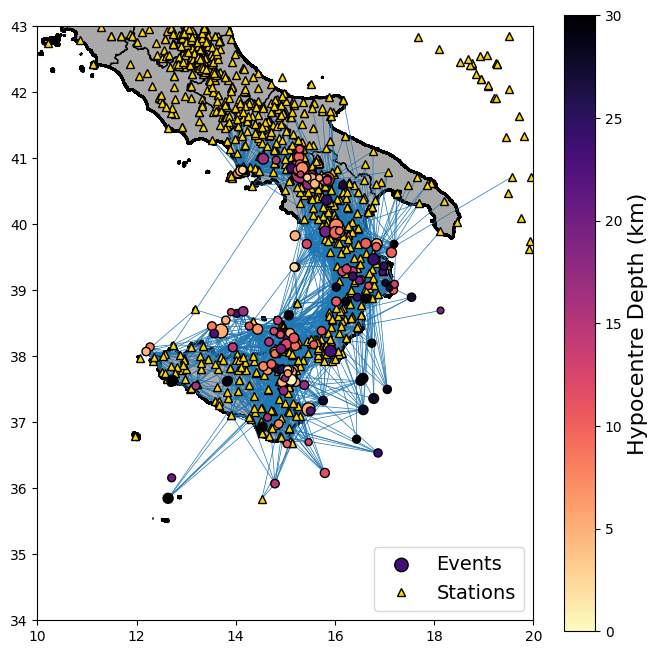

In [24]:
from matplotlib.collections import LineCollection

fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
# Plot the event-to-site paths as a Line Collection
paths = []
for i, row in flatfile.iterrows():
    paths.append([(row.event_longitude, row.event_latitude), (row.station_longitude, row.station_latitude)])
paths = LineCollection(paths, colors="tab:blue", linewidth=0.5)
ax.add_collection(paths)
# Plot the epicentres
cax = ax.scatter(source_table["event_longitude"], source_table["event_latitude"],
                 c=source_table["event_depth"].to_numpy(), s=0.5 * source_table["mag"].to_numpy().astype(float) ** 3.0,
                 marker="o", edgecolor="k", cmap="magma_r", norm=Normalize(0.0, 30.0), label="Events", zorder=4)
# Plot the stations
unique_stations = stations.drop_duplicates(["network_code", "station_code"], inplace=False)
ax.plot(unique_stations["station_longitude"], unique_stations["station_latitude"], "^", mec="k", mfc="gold", label="Stations")
ax.set_xlim(w - 2, e + 2)
ax.set_ylim(s - 2, n + 2)
cbar = fig.colorbar(cax)
cbar.ax.set_ylabel("Hypocentre Depth (km)", fontsize=16)
ax.legend(loc="lower right", fontsize=14)

### For later interest ... how many records do we have per event? 

In [34]:
event_count= flatfile.value_counts("event_id")
for evid, nrec in zip(event_count.index, event_count.to_numpy()):
    print(f"Event {evid} - {nrec} records")

Event INT-39921481 - 165 records
Event INT-20250318_0000113 - 127 records
Event INT-20250207_0000299 - 103 records
Event EMSC-20200224_0000188 - 98 records
Event INT-44522982 - 92 records
Event EMSC-20200317_0000006 - 79 records
Event EMSC-20191025_0000044 - 72 records
Event INT-41908352 - 69 records
Event IT-2012-0061 - 67 records
Event INT-40949681 - 65 records
Event EMSC-20201222_0000154 - 60 records
Event INT-20210831_0000041 - 59 records
Event INT-42698352 - 57 records
Event INT-20220120_0000080 - 56 records
Event EMSC-20181006_0000002 - 52 records
Event INT-38759141 - 51 records
Event EMSC-20150803_0000020 - 49 records
Event INT-20211223_0000236 - 49 records
Event EMSC-20200116_0000172 - 48 records
Event INT-20221204_0000048 - 47 records
Event EMSC-20141228_0000068 - 46 records
Event INT-20230528_0000042 - 45 records
Event INT-43270472 - 43 records
Event EMSC-20191007_0000023 - 39 records
Event INT-38762031 - 39 records
Event INT-43451602 - 39 records
Event INT-35654731 - 37 reco

### And how many records per station?

In [33]:
site_count = flatfile.value_counts("site_id")
for sid, nrec in zip(site_count.index, site_count.to_numpy()):
    print(f"Site {sid} - {nrec} records")

Site IV.EVRN..HN - 34 records
Site IV.PLAC..HN - 33 records
Site IV.JOPP..HN - 31 records
Site MN.CEL..HN - 31 records
Site IV.SERS..HN - 27 records
Site IV.CELI..HN - 27 records
Site IV.EPOZ..HN - 26 records
Site IV.CAR1..HN - 25 records
Site MN.TIP..HN - 25 records
Site MN.CUC..HN - 23 records
Site IV.SSY..HN - 21 records
Site IV.PIPA..HN - 19 records
Site IT.PTT..HG - 19 records
Site IT.TOR..HN - 18 records
Site IV.HVZN..HN - 18 records
Site IV.ACER..HN - 17 records
Site IT.FDF..HG - 17 records
Site IT.BNT..HN - 16 records
Site IT.RSN..HN - 16 records
Site IT.SRT..HG - 16 records
Site IV.EMCN..HN - 16 records
Site IT.SGV..HN - 15 records
Site IT.SVN..HN - 15 records
Site IV.IVPL..HN - 15 records
Site IV.ECHR..HN - 15 records
Site IV.SALB..HN - 15 records
Site IT.LNT..HG - 15 records
Site IT.PTT..HN - 14 records
Site IT.ACR..HN - 14 records
Site IT.SPS..HN - 14 records
Site IV.BULG..HN - 14 records
Site IT.NAS..HG - 14 records
Site IT.TOR..HG - 14 records
Site IT.RCU..HG - 14 records